## Домашнє завдання


Налаштувалися на виконання нового завдання? Тодi починаємо!

Сьогодні використаєте знання з генетичних алгоритмів для розв'язання задачі про рюкзак у тому варіанті, що розглядався в конспекті.

Це допоможе вам закрiпити навички:

- попередньої підготовки даних до моделювання;
- роботу з бібліотекою PyGad.


## Завдання (крок за кроком)

Будемо використовувати дані про 14 товарів з прикладу в конспекті.

Для виконання завдання необхідно виконати такі кроки:

1. Завантажити біблітеку PyGad

2. Визначити окремо в коді фітнес функцію.

3. Визначити початкову популяцію.

4. Задати параметри генетичного алгоритму: кількість популяцій, кількість батьківських хромосом, що приймають участь у кросовері, тип кросовера та мутації тощо.

5. Створити екземпляр генеричного алгоритму засобами PyGad.

6. Дослідити вплив різних кросоверів та мутацій на результат.

7. Зробити висновок про ефективність застосування генетичного алгоритму та оптимальний набір його параметрів.

## Пiдказки

Для виконання завдання використовуй функції та алгоритми з конспекту до цієї теми та з завдання до ДЗ.

## Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийняття завдання

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

## Формат оцінювання
Залiк / Незалiк

## Приклад

A Complete Guide to Genetic Algorithm – Advantages, Limitations & More

https://www.analytixlabs.co.in/blog/genetic-algorithm/#Running_a_Genetic_Algorithm_in_Python

Rastrigin function


https://en.wikipedia.org/wiki/Rastrigin_function

In [1]:
!pip install pygad

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import pygad

def rastrigin(X):
    A = 10
    return A * len(X) + sum([(x**2 - A * np.cos(2 * np.pi * x)) for x in X])


def plot_rastrigin_2d():
    x = np.linspace(-5.12, 5.12, 200)
    y = np.linspace(-5.12, 5.12, 200)
    X, Y = np.meshgrid(x, y)
    A = 10
    Z = A * 2 + (X**2 - A * np.cos(2 * np.pi * X)) + (Y**2 - A * np.cos(2 * np.pi * Y))

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title('Функція Rastrigin')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x, y)')
    plt.show()


Фітнес-функція (мінімізуємо Rastrigin => беремо -f)

In [3]:
def fitness_func(ga, solution, solution_idx):
    return -rastrigin(solution)


Обчислювальний експеримент із різними типами кросоверу та мутації

Документація бібліотеки

https://pygad.readthedocs.io/en/latest/pygad.html

In [4]:
def genetic_experiment():
    crossover_types = ["single_point", "two_points", "uniform", "scattered"]
    mutation_types = ["random", "swap", "inversion", "scramble"]
    results = []
    num_genes = 2
    gene_space = {'low': -5.12, 'high': 5.12}

    for crossover in crossover_types:
        for mutation in mutation_types:
            try:
                ga = pygad.GA(
                    num_generations=1000,
                    num_parents_mating=2,
                    fitness_func=fitness_func,
                    sol_per_pop=10,
                    num_genes=num_genes,
                    gene_space=gene_space,
                    parent_selection_type="rank",
                    crossover_type=crossover,
                    mutation_type=mutation,
                    mutation_percent_genes=40,

                    random_mutation_min_val=-1.0,
                    random_mutation_max_val=1.0,
                    suppress_warnings=True
                )
                ga.run()
                best_sol, best_fit, _ = ga.best_solution()
                results.append({
                    "Crossover": crossover,
                    "Mutation": mutation,
                    "Fitness (−Rastrigin)": best_fit,
                    "Solution": np.round(best_sol, 3).tolist()
                })
            except Exception as e:
                results.append({
                    "Crossover": crossover,
                    "Mutation": mutation,
                    "Fitness (−Rastrigin)": None,
                    "Solution": str(e)
                })
    return pd.DataFrame(results)




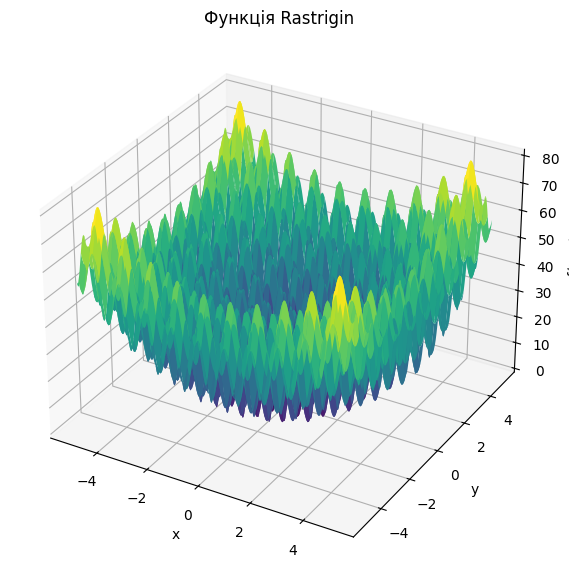

,Crossover,Mutation,Fitness (−Rastrigin),Solution
0,two_points,swap,-0.002753,"[-0.003, -0.003]"
1,scattered,random,-0.120911,"[-0.024, 0.006]"
2,uniform,random,-0.240133,"[0.034, 0.006]"
3,two_points,random,-0.330193,"[-0.033, -0.024]"
4,uniform,swap,-0.961987,"[0.049, 0.049]"
5,single_point,random,-1.017650,"[0.062, 0.037]"
6,scattered,swap,-2.339727,"[1.025, 1.025]"
7,uniform,inversion,-7.406391,"[-0.054, -1.175]"
8,two_points,scramble,-7.948045,"[1.002, -1.177]"
9,single_point,swap,-9.389330,"[-2.05, -2.05]"


In [5]:
plot_rastrigin_2d()
results_df = genetic_experiment()
results_df.sort_values("Fitness (−Rastrigin)", ascending=False).reset_index(drop=True)


---
# Виконання домашнього завдання
## Розв'язання задачі про рюкзак (0/1 Knapsack) генетичним алгоритмом засобами PyGAD

**Постановка задачі.** Є $n = 14$ товарів, кожен має вагу $w_i$ та цінність $v_i$. Рюкзак витримує не більше $W_{max}$.
Потрібно обрати підмножину товарів $x_i \in \{0, 1\}$, яка максимізує сумарну цінність при обмеженні на вагу:

$$\max \sum_{i=1}^{n} v_i x_i, \qquad \text{за умови} \quad \sum_{i=1}^{n} w_i x_i \le W_{max}.$$

**Кодування для ГА:** хромосома — бінарний вектор довжиною 14 (ген = 1, якщо товар покладено в рюкзак).

**План роботи:**
1. Завантаження бібліотеки PyGAD
2. Дані та фітнес-функція
3. Початкова популяція
4. Параметри генетичного алгоритму
5. Створення та запуск екземпляра `pygad.GA`
6. Дослідження впливу кросоверів, мутацій та інших параметрів
7. Висновки

## Крок 1. Завантаження бібліотеки PyGAD та імпорт модулів

In [6]:
!pip install -q pygad

In [7]:
import itertools
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pygad

print('PyGAD version:', pygad.__version__)
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200)

PyGAD version: 3.7.0


## Підготовка даних: 14 товарів

Використовуємо набір із 14 товарів (назва, вага в кг, цінність у балах) і місткість рюкзака $W_{max} = 10$ кг.

> Якщо значення ваг/цінностей у вашому конспекті інші — достатньо замінити їх у цій комірці,
> увесь подальший код (включно з точним розв'язком для перевірки) перерахується автоматично.

In [8]:
items = pd.DataFrame({
    'item':   ['Намет', 'Спальник', 'Каремат', 'Пальник', 'Казанок', 'Вода', 'Їжа',
               'Аптечка', 'Ліхтарик', 'Павербанк', 'Куртка', 'Ніж', 'Карта', 'Фотоапарат'],
    'weight': [3.5, 1.8, 0.8, 0.6, 0.9, 3.0, 2.5, 0.5, 0.3, 0.4, 1.2, 0.2, 0.1, 1.5],
    'value':  [10,  9,   6,   5,   4,   10,  9,   8,   5,   4,   6,   5,   3,   2],
})
items['value_per_kg'] = (items['value'] / items['weight']).round(2)

CAPACITY = 10.0
WEIGHTS = items['weight'].values
VALUES = items['value'].values
NUM_GENES = len(items)

print(f'Кількість товарів: {NUM_GENES}')
print(f'Місткість рюкзака: {CAPACITY} кг')
print(f'Сумарна вага всіх товарів: {WEIGHTS.sum():.1f} кг, сумарна цінність: {VALUES.sum()}')
print(f'Розмір простору розв\'язків: 2^{NUM_GENES} = {2**NUM_GENES}')
items

Кількість товарів: 14
Місткість рюкзака: 10.0 кг
Сумарна вага всіх товарів: 17.3 кг, сумарна цінність: 86
Розмір простору розв'язків: 2^14 = 16384


,item,weight,value,value_per_kg
0,Намет,3.5,10,2.86
1,Спальник,1.8,9,5.00
2,Каремат,0.8,6,7.50
3,Пальник,0.6,5,8.33
4,Казанок,0.9,4,4.44
5,Вода,3.0,10,3.33
6,Їжа,2.5,9,3.60
7,Аптечка,0.5,8,16.00
8,Ліхтарик,0.3,5,16.67
9,Павербанк,0.4,4,10.00


Сумарна вага всіх товарів (17.3 кг) значно перевищує місткість (10 кг), тож задача нетривіальна — потрібно відмовитись приблизно від третини ваги.

**Еталонний розв'язок.** Простір розв'язків маленький ($2^{14} = 16384$ варіанти), тому точний оптимум можна знайти повним перебором.
Він потрібен лише для **оцінки якості ГА** (у реальних задачах з сотнями товарів перебір неможливий — саме тоді і потрібні евристики).

In [9]:
def decode(solution):
    """Повертає вагу, цінність і список товарів для хромосоми."""
    sol = np.asarray(solution, dtype=int)
    return WEIGHTS @ sol, VALUES @ sol, items.loc[sol == 1, 'item'].tolist()

t0 = time.time()
best_value, best_x = -1, None
for bits in itertools.product([0, 1], repeat=NUM_GENES):
    x = np.array(bits)
    if WEIGHTS @ x <= CAPACITY and VALUES @ x > best_value:
        best_value, best_x = VALUES @ x, x
OPTIMUM = int(best_value)

w, v, names = decode(best_x)
print(f'Повний перебір: {time.time() - t0:.2f} c')
print(f'Оптимальна цінність: {OPTIMUM}, вага: {w:.1f} кг')
print('Хромосома:', best_x.tolist())
print('Товари:', ', '.join(names))

Повний перебір: 0.05 c
Оптимальна цінність: 65, вага: 9.8 кг
Хромосома: [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]
Товари: Спальник, Каремат, Пальник, Казанок, Вода, Аптечка, Ліхтарик, Павербанк, Куртка, Ніж, Карта


## Крок 2. Фітнес-функція

Фітнес-функція повинна:
- для **допустимих** розв'язків (вага ≤ місткості) повертати сумарну цінність — її максимізуємо;
- для **недопустимих** (перевантажених) — повертати значення, гірше за будь-який допустимий розв'язок.

Використовуємо **штрафну функцію**: для перевантаженого рюкзака фітнес = $-(\text{перевага})$, тобто від'ємне число,
яке тим ближче до 0, чим менше перевантаження. Так алгоритм отримує «градієнт» — навіть серед недопустимих
розв'язків кращими вважаються ті, що ближчі до межі допустимості. (Альтернатива — «смертельний штраф» = 0 — порівняємо на кроці 6.)

In [10]:
def fitness_func(ga_instance, solution, solution_idx):
    total_weight = np.dot(WEIGHTS, solution)
    total_value = np.dot(VALUES, solution)
    if total_weight <= CAPACITY:
        return float(total_value)               # допустимий розв'язок
    return -float(total_weight - CAPACITY)      # штраф за перевантаження (< 0)


def fitness_func_death(ga_instance, solution, solution_idx):
    """Альтернатива: «смертельний штраф» — перевантажений рюкзак має фітнес 0."""
    total_weight = np.dot(WEIGHTS, solution)
    return float(np.dot(VALUES, solution)) if total_weight <= CAPACITY else 0.0


# Перевірка фітнес-функції
print('Оптимальний розв\'язок   :', fitness_func(None, best_x, 0))
print('Порожній рюкзак          :', fitness_func(None, np.zeros(NUM_GENES, int), 0))
print('Усі товари (перевантаж.) :', fitness_func(None, np.ones(NUM_GENES, int), 0))

Оптимальний розв'язок   : 65.0
Порожній рюкзак          : 0.0
Усі товари (перевантаж.) : -7.299999999999997


## Крок 3. Початкова популяція

Формуємо початкову популяцію з `SOL_PER_POP = 20` хромосом. Кожен ген — 0 або 1 з імовірністю 0.5
(у середньому в рюкзак кладеться 7 товарів ≈ 8.6 кг, тож частина хромосом буде допустимою, частина — перевантаженою).
Фіксуємо `seed` для відтворюваності.

In [11]:
SOL_PER_POP = 20

def make_initial_population(sol_per_pop=SOL_PER_POP, num_genes=NUM_GENES, p_one=0.5, seed=0):
    rng = np.random.default_rng(seed)
    return (rng.random((sol_per_pop, num_genes)) < p_one).astype(int)

initial_population = make_initial_population()

pop_info = pd.DataFrame(initial_population, columns=[f'g{i}' for i in range(NUM_GENES)])
pop_info['weight'] = initial_population @ WEIGHTS
pop_info['value'] = initial_population @ VALUES
pop_info['fitness'] = [fitness_func(None, s, i) for i, s in enumerate(initial_population)]
pop_info['feasible'] = pop_info['weight'] <= CAPACITY

print('Розмір популяції:', initial_population.shape)
print('Допустимих хромосом:', pop_info['feasible'].sum(), 'з', SOL_PER_POP)
print('Найкращий фітнес у початковій популяції:', pop_info['fitness'].max())
pop_info

Розмір популяції: (20, 14)
Допустимих хромосом: 16 з 20
Найкращий фітнес у початковій популяції: 45.0


,g0,g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12,g13,weight,value,fitness,feasible
0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,4.9,27,27.0,True
1,0,1,0,0,1,1,1,1,0,0,0,1,0,0,8.9,45,45.0,True
2,0,0,0,1,1,0,0,1,1,0,0,1,0,1,4.0,29,29.0,True
3,0,1,1,0,1,0,1,0,0,1,0,1,1,1,8.2,42,42.0,True
4,1,0,1,1,1,1,1,0,1,0,1,0,1,1,14.4,60,-4.4,False
5,0,0,1,0,1,1,0,0,0,1,0,1,0,0,5.3,29,29.0,True
6,1,0,0,0,1,0,0,0,1,0,0,0,1,0,4.8,22,22.0,True
7,0,0,1,1,0,0,1,0,1,0,1,0,0,1,6.9,33,33.0,True
8,0,1,0,0,0,1,0,1,1,1,0,0,1,1,7.6,41,41.0,True
9,0,1,1,1,0,0,0,0,1,1,0,0,0,1,5.4,31,31.0,True


## Крок 4. Параметри генетичного алгоритму

| Параметр | Значення | Пояснення |
|---|---|---|
| `num_generations` | 50 | кількість поколінь (ітерацій) |
| `sol_per_pop` | 20 | розмір популяції |
| `num_parents_mating` | 6 | кількість батьківських хромосом, що беруть участь у кросовері |
| `num_genes` | 14 | довжина хромосоми = кількість товарів |
| `gene_space` | `[0, 1]` | ген може бути лише 0 або 1 (бінарне кодування) |
| `gene_type` | `int` | цілочисельні гени |
| `parent_selection_type` | `'tournament'`, `K_tournament=3` | турнірна селекція батьків |
| `keep_elitism` | 1 | найкраща хромосома завжди переходить у наступне покоління |
| `crossover_type` | `'single_point'` | одноточковий кросовер (базовий варіант) |
| `crossover_probability` | 0.9 | ймовірність застосування кросовера до пари батьків |
| `mutation_type` | `'random'` | випадкова мутація (з `gene_space` — інверсія біта 0↔1) |
| `mutation_probability` | 0.1 | ймовірність мутації кожного гена |

In [12]:
BASE_PARAMS = dict(
    num_generations=50,
    sol_per_pop=SOL_PER_POP,
    num_parents_mating=6,
    num_genes=NUM_GENES,
    gene_space=[0, 1],
    gene_type=int,
    fitness_func=fitness_func,
    parent_selection_type='tournament',
    K_tournament=3,
    keep_elitism=1,
    crossover_type='single_point',
    crossover_probability=0.9,
    mutation_type='random',
    mutation_probability=0.1,
    suppress_warnings=True,
)
BASE_PARAMS

{'num_generations': 50,
 'sol_per_pop': 20,
 'num_parents_mating': 6,
 'num_genes': 14,
 'gene_space': [0, 1],
 'gene_type': int,
 'fitness_func': <function __main__.fitness_func(ga_instance, solution, solution_idx)>,
 'parent_selection_type': 'tournament',
 'K_tournament': 3,
 'keep_elitism': 1,
 'crossover_type': 'single_point',
 'crossover_probability': 0.9,
 'mutation_type': 'random',
 'mutation_probability': 0.1,
 'suppress_warnings': True}

## Крок 5. Створення екземпляра генетичного алгоритму та його запуск

Додаємо `on_generation` для збереження статистики кожного покоління (найкращий і середній фітнес популяції).

In [13]:
history = {'best': [], 'mean': []}

def on_generation(ga):
    fit = ga.last_generation_fitness
    history['best'].append(np.max(fit))
    history['mean'].append(np.mean(fit[fit >= 0]) if np.any(fit >= 0) else np.nan)

ga_instance = pygad.GA(
    initial_population=initial_population,
    on_generation=on_generation,
    random_seed=42,
    **{k: v for k, v in BASE_PARAMS.items() if k not in ('sol_per_pop', 'num_genes')}
)
ga_instance.run()

solution, solution_fitness, solution_idx = ga_instance.best_solution()
w, v, names = decode(solution)
print('Найкраща хромосома :', solution.tolist())
print(f'Фітнес             : {solution_fitness}')
print(f'Цінність / вага    : {v} / {w:.1f} кг (місткість {CAPACITY} кг)')
print('Товари в рюкзаку   :', ', '.join(names))
print('Знайдено в поколінні:', ga_instance.best_solution_generation)
print(f'Глобальний оптимум  : {OPTIMUM} -> знайдено {"так" if v == OPTIMUM else "ні"} '
      f'({100 * v / OPTIMUM:.1f}% від оптимуму)')

Найкраща хромосома : [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]
Фітнес             : 65.0
Цінність / вага    : 65 / 9.8 кг (місткість 10.0 кг)
Товари в рюкзаку   : Спальник, Каремат, Пальник, Казанок, Вода, Аптечка, Ліхтарик, Павербанк, Куртка, Ніж, Карта
Знайдено в поколінні: 6
Глобальний оптимум  : 65 -> знайдено так (100.0% від оптимуму)


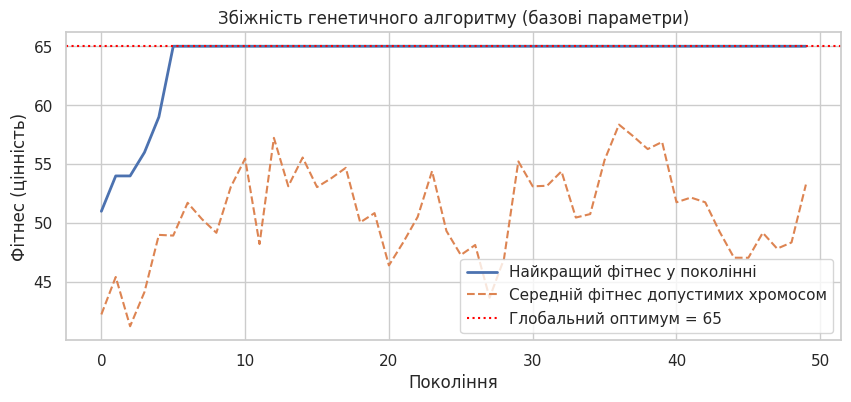

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['best'], label='Найкращий фітнес у поколінні', lw=2)
ax.plot(history['mean'], label='Середній фітнес допустимих хромосом', lw=1.5, ls='--')
ax.axhline(OPTIMUM, color='red', ls=':', label=f'Глобальний оптимум = {OPTIMUM}')
ax.set_xlabel('Покоління')
ax.set_ylabel('Фітнес (цінність)')
ax.set_title('Збіжність генетичного алгоритму (базові параметри)')
ax.legend()
plt.show()

In [15]:
result_table = items.assign(selected=solution.astype(bool))
result_table.style.apply(lambda r: ['background-color: #c7e9c0' if r['selected'] else '' for _ in r], axis=1)

,item,weight,value,value_per_kg,selected
0,Намет,3.500000,10,2.860000,False
1,Спальник,1.800000,9,5.000000,True
2,Каремат,0.800000,6,7.500000,True
3,Пальник,0.600000,5,8.330000,True
4,Казанок,0.900000,4,4.440000,True
5,Вода,3.000000,10,3.330000,True
6,Їжа,2.500000,9,3.600000,False
7,Аптечка,0.500000,8,16.000000,True
8,Ліхтарик,0.300000,5,16.670000,True
9,Павербанк,0.400000,4,10.000000,True


**Результат кроку 5:** ГА з базовими параметрами знаходить розв'язок високої якості за кілька десятків поколінь,
переглянувши лише ≈ 20 × 50 = 1000 хромосом (≈ 6% простору пошуку). Найкращий фітнес монотонно не спадає завдяки елітизму,
середній фітнес популяції теж зростає — популяція поступово концентрується навколо хороших розв'язків.

## Крок 6. Дослідження впливу різних кросоверів та мутацій на результат

ГА — стохастичний алгоритм, тому один запуск нічого не доводить. Для кожної комбінації параметрів робимо
**30 незалежних запусків** (різні `random_seed`) і рахуємо:
- **mean_fitness** — середній найкращий фітнес;
- **success_rate** — частку запусків, у яких знайдено глобальний оптимум;
- **mean_best_gen** — середнє покоління, в якому знайдено найкращий розв'язок (швидкість збіжності);
- **time_s** — середній час одного запуску.

Типи кросовера: `single_point`, `two_points`, `uniform`, `scattered`.
Типи мутації: `random`, `swap`, `inversion`, `scramble` (+ `adaptive` окремо).

In [16]:
N_RUNS = 30

def run_ga(seed, **overrides):
    params = {**BASE_PARAMS, **overrides}
    t = time.time()
    ga = pygad.GA(random_seed=seed, **params)
    ga.run()
    sol, fit, _ = ga.best_solution()
    return {'fitness': fit, 'best_gen': ga.best_solution_generation, 'time_s': time.time() - t,
            'feasible': WEIGHTS @ sol <= CAPACITY}

def experiment(n_runs=N_RUNS, **overrides):
    runs = pd.DataFrame([run_ga(seed, **overrides) for seed in range(n_runs)])
    return {'mean_fitness': runs['fitness'].mean(),
            'std_fitness': runs['fitness'].std(),
            'min_fitness': runs['fitness'].min(),
            'success_rate': (runs['fitness'] == OPTIMUM).mean(),
            'mean_best_gen': runs['best_gen'].mean(),
            'time_s': runs['time_s'].mean()}

### 6.1. Комбінації «кросовер × мутація»

In [17]:
crossover_types = ['single_point', 'two_points', 'uniform', 'scattered']
mutation_types = ['random', 'swap', 'inversion', 'scramble']

rows = []
for cx in crossover_types:
    for mut in mutation_types:
        rows.append({'crossover': cx, 'mutation': mut, **experiment(crossover_type=cx, mutation_type=mut)})
res_cm = pd.DataFrame(rows)
res_cm.sort_values(['success_rate', 'mean_fitness'], ascending=False).round(3).reset_index(drop=True)

,crossover,mutation,mean_fitness,std_fitness,min_fitness,success_rate,mean_best_gen,time_s
0,uniform,scramble,65.000,0.000,65.0,1.000,18.400,0.032
1,scattered,scramble,65.000,0.000,65.0,1.000,18.400,0.033
2,two_points,scramble,64.900,0.548,62.0,0.967,16.833,0.032
3,two_points,inversion,64.567,1.716,56.0,0.900,19.333,0.028
4,single_point,scramble,64.600,1.037,62.0,0.867,16.700,0.036
5,single_point,random,64.533,1.306,59.0,0.800,22.533,0.030
6,two_points,random,64.767,0.430,64.0,0.767,22.500,0.032
7,single_point,inversion,64.167,1.663,60.0,0.733,21.900,0.026
8,uniform,inversion,63.667,2.644,56.0,0.700,17.400,0.030
9,scattered,inversion,63.667,2.644,56.0,0.700,17.400,0.028


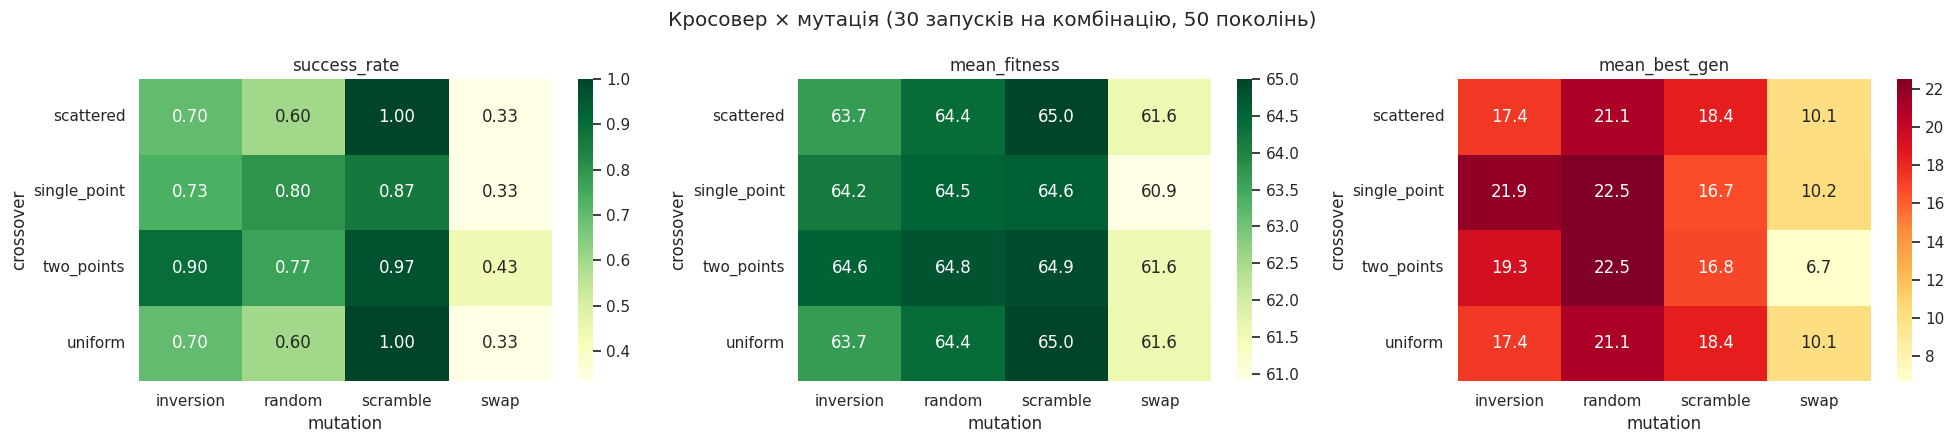

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for ax, metric, cmap, fmt in zip(axes, ['success_rate', 'mean_fitness', 'mean_best_gen'],
                                 ['YlGn', 'YlGn', 'YlOrRd'], ['.2f', '.1f', '.1f']):
    sns.heatmap(res_cm.pivot(index='crossover', columns='mutation', values=metric),
                annot=True, fmt=fmt, cmap=cmap, ax=ax)
    ax.set_title(metric)
plt.suptitle(f'Кросовер × мутація ({N_RUNS} запусків на комбінацію, {BASE_PARAMS["num_generations"]} поколінь)')
plt.tight_layout()
plt.show()

### 6.2. Криві збіжності для різних типів мутації та кросовера

Усереднений по 30 запускам найкращий фітнес у кожному поколінні.

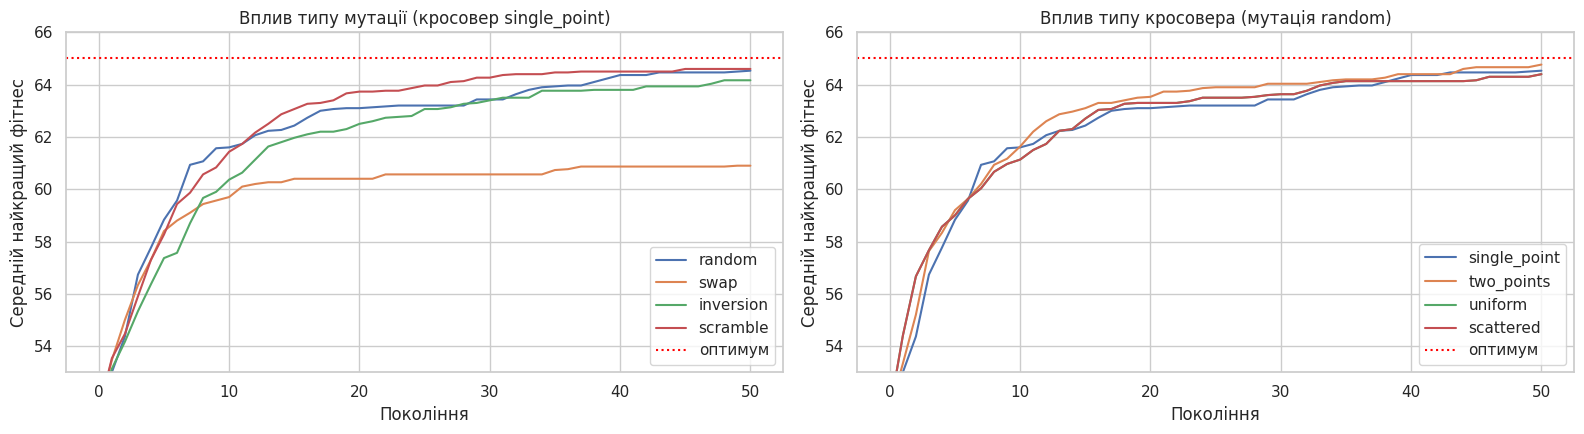

In [19]:
def mean_curve(n_runs=N_RUNS, **overrides):
    curves = []
    for seed in range(n_runs):
        ga = pygad.GA(random_seed=seed, **{**BASE_PARAMS, **overrides})
        ga.run()
        curves.append(ga.best_solutions_fitness)
    return np.mean(curves, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for mut in mutation_types:
    axes[0].plot(mean_curve(mutation_type=mut), label=mut)
axes[0].set_title('Вплив типу мутації (кросовер single_point)')
for cx in crossover_types:
    axes[1].plot(mean_curve(crossover_type=cx), label=cx)
axes[1].set_title('Вплив типу кросовера (мутація random)')
for ax in axes:
    ax.axhline(OPTIMUM, color='red', ls=':', label='оптимум')
    ax.set_ylim(OPTIMUM - 12, OPTIMUM + 1)
    ax.set_xlabel('Покоління'); ax.set_ylabel('Середній найкращий фітнес'); ax.legend()
plt.tight_layout()
plt.show()

### 6.3. Вплив ймовірності мутації (`random`) та адаптивної мутації

,mutation,mean_fitness,std_fitness,min_fitness,success_rate,mean_best_gen,time_s
0,"random, p=0.01",60.200,3.056,53.0,0.100,11.267,0.022
1,"random, p=0.03",62.400,2.541,57.0,0.333,20.433,0.024
2,"random, p=0.05",63.833,2.086,57.0,0.633,23.367,0.025
3,"random, p=0.1",64.533,1.306,59.0,0.800,22.533,0.031
4,"random, p=0.15",64.233,1.357,59.0,0.567,23.000,0.034
5,"random, p=0.2",64.100,1.583,60.0,0.667,23.833,0.038
6,"random, p=0.3",61.967,1.974,59.0,0.200,22.067,0.045
7,"random, p=0.5",60.700,2.168,58.0,0.133,23.100,0.061
8,"adaptive, p=(0.25, 0.05)",64.233,1.431,61.0,0.700,24.133,0.035


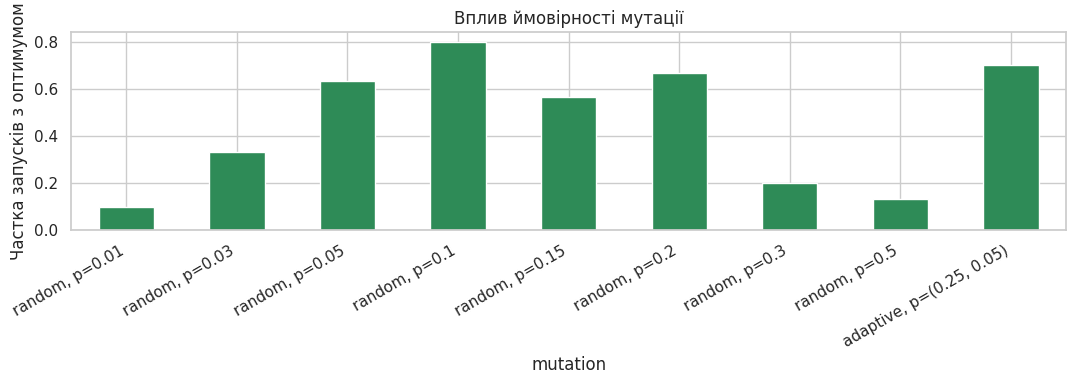

In [20]:
rows = []
for p in [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    rows.append({'mutation': f'random, p={p}', **experiment(mutation_type='random', mutation_probability=p)})
rows.append({'mutation': 'adaptive, p=(0.25, 0.05)',
             **experiment(mutation_type='adaptive', mutation_probability=(0.25, 0.05))})
res_mp = pd.DataFrame(rows)
display(res_mp.round(3))

ax = res_mp.set_index('mutation')[['success_rate']].plot.bar(figsize=(11, 4), legend=False, color='seagreen')
ax.set_ylabel('Частка запусків з оптимумом'); ax.set_title('Вплив ймовірності мутації')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### 6.4. Вплив способу селекції батьків, кількості батьків і розміру популяції

In [21]:
rows = []
for sel in ['sss', 'rws', 'sus', 'rank', 'random', 'tournament']:
    rows.append({'parameter': 'parent_selection_type', 'value': sel, **experiment(parent_selection_type=sel)})
for npm in [2, 4, 6, 10]:
    rows.append({'parameter': 'num_parents_mating', 'value': npm, **experiment(num_parents_mating=npm)})
for spp in [10, 20, 40]:
    rows.append({'parameter': 'sol_per_pop', 'value': spp,
                 **experiment(sol_per_pop=spp, num_parents_mating=min(6, spp))})
for el in [0, 1, 2]:
    rows.append({'parameter': 'keep_elitism', 'value': el, **experiment(keep_elitism=el)})
res_other = pd.DataFrame(rows)
res_other.round(3)

,parameter,value,mean_fitness,std_fitness,min_fitness,success_rate,mean_best_gen,time_s
0,parent_selection_type,sss,64.700,0.915,61.0,0.867,18.800,0.028
1,parent_selection_type,rws,63.667,1.768,59.0,0.467,26.633,0.028
2,parent_selection_type,sus,63.467,1.655,60.0,0.333,23.600,0.028
3,parent_selection_type,rank,58.200,2.140,53.0,0.000,23.267,0.030
4,parent_selection_type,random,61.633,2.282,58.0,0.200,29.400,0.028
5,parent_selection_type,tournament,64.533,1.306,59.0,0.800,22.533,0.032
6,num_parents_mating,2,63.800,1.750,59.0,0.567,21.167,0.028
7,num_parents_mating,4,64.467,1.042,61.0,0.700,20.267,0.029
8,num_parents_mating,6,64.533,1.306,59.0,0.800,22.533,0.030
9,num_parents_mating,10,64.733,0.450,64.0,0.733,19.533,0.031


### 6.5. Вплив виду фітнес-функції (градуйований штраф vs «смертельний штраф»)

In [22]:
rows = []
for name, ff in [('градуйований штраф', fitness_func), ('смертельний штраф (0)', fitness_func_death)]:
    for p_one, label in [(0.5, 'p(1)=0.5'), (0.8, 'p(1)=0.8 (перевантажена поч. популяція)')]:
        runs = []
        for seed in range(N_RUNS):
            init = make_initial_population(p_one=p_one, seed=seed)
            params = {k: v for k, v in BASE_PARAMS.items() if k not in ('sol_per_pop', 'num_genes', 'fitness_func')}
            ga = pygad.GA(initial_population=init, fitness_func=ff, random_seed=seed, **params)
            ga.run()
            sol, _, _ = ga.best_solution()
            val = VALUES @ sol if WEIGHTS @ sol <= CAPACITY else 0
            runs.append(val)
        runs = np.array(runs)
        rows.append({'fitness': name, 'initial_population': label,
                     'mean_value': runs.mean(), 'success_rate': (runs == OPTIMUM).mean()})
pd.DataFrame(rows).round(3)

,fitness,initial_population,mean_value,success_rate
0,градуйований штраф,p(1)=0.5,64.600,0.833
1,градуйований штраф,p(1)=0.8 (перевантажена поч. популяція),64.667,0.767
2,смертельний штраф (0),p(1)=0.5,64.433,0.833
3,смертельний штраф (0),p(1)=0.8 (перевантажена поч. популяція),64.633,0.833


### 6.6. Найкраща конфігурація
Об'єднуємо найкращі знайдені налаштування (кросовер `uniform`, мутація `scramble`, турнірна селекція, елітизм, популяція 40) і перевіряємо їх на 100 запусках у порівнянні з базовою та найгіршою конфігураціями.

In [23]:
BEST_OVERRIDES = dict(crossover_type='uniform', mutation_type='scramble',
                      parent_selection_type='tournament', K_tournament=3,
                      num_parents_mating=6, keep_elitism=1, sol_per_pop=40)

comparison = pd.DataFrame([
    {'config': 'базова (single_point + random, pop=20)', **experiment(n_runs=100)},
    {'config': 'uniform + scramble, pop=20', **experiment(n_runs=100, crossover_type='uniform', mutation_type='scramble')},
    {'config': 'найкраща: uniform + scramble, pop=40', **experiment(n_runs=100, **BEST_OVERRIDES)},
    {'config': 'базова, 100 поколінь', **experiment(n_runs=100, num_generations=100)},
    {'config': 'single_point + swap (найгірша)', **experiment(n_runs=100, mutation_type='swap')},
])
comparison.round(3)

,config,mean_fitness,std_fitness,min_fitness,success_rate,mean_best_gen,time_s
0,"базова (single_point + random, pop=20)",64.43,1.312,59.0,0.74,20.89,0.029
1,"uniform + scramble, pop=20",64.85,0.657,62.0,0.95,17.43,0.033
2,"найкраща: uniform + scramble, pop=40",64.97,0.300,62.0,0.99,13.97,0.057
3,"базова, 100 поколінь",64.97,0.171,64.0,0.97,31.93,0.056
4,single_point + swap (найгірша),61.55,3.563,53.0,0.45,11.90,0.023


### Висновки кроку 6

**Кросовер × мутація (6.1–6.2):**
- **Тип мутації впливає сильніше, ніж тип кросовера.** Найкращі результати дає мутація **`scramble`**
  (у парі з `uniform`/`scattered` — оптимум у 100% із 30 запусків, з `two_points` — 97%), далі `random` та `inversion` (60–90%).
- **Мутація `swap` — найгірша** (успіх лише 33–43%, середній фітнес ≈ 61): вона лише міняє місцями два гени і **не змінює кількість
  обраних товарів**, тому популяція рано «застрягає» (найкращий розв'язок знаходиться вже на 7–10 поколінні і далі не покращується —
  передчасна збіжність). `inversion` і `scramble` теж зберігають кількість одиниць, але перемішують цілий сегмент і краще досліджують простір;
  кількість товарів змінюють кросовер та елітні нащадки.
- Тип кросовера має другорядний вплив: на кривих збіжності всі чотири варіанти близькі; `two_points` і `uniform` дещо стабільніші.
  `uniform` і `scattered` у PyGAD дають **ідентичні** результати (обидва обирають кожен ген від випадкового з батьків).

**Ймовірність мутації (6.3):** залежність має форму «дзвона». Занадто мала ймовірність (0.01–0.03) — мало різноманіття, передчасна збіжність
(успіх 10–33%); занадто велика (0.3–0.5) — алгоритм перетворюється на випадковий пошук і руйнує хороші розв'язки (успіх 13–20%).
**Оптимум ≈ 0.1** (≈ 1–2 гени з 14 на хромосому, успіх 80%). Адаптивна мутація (0.25 → 0.05) дає близький результат (70%) без ручного підбору.

**Селекція, батьки, популяція, елітизм (6.4):**
- Найкраще працюють **турнірна** (`tournament`, 80%) і steady-state (`sss`, 87%) селекції. Пропорційні (`rws`, `sus`) слабші (33–47%),
  бо фітнеси хромосом близькі (50–65) і тиск відбору малий; `rank` у цій конфігурації взагалі не знайшла оптимуму, `random` — 20%.
- Збільшення `num_parents_mating` з 2 до 6–10 підвищує якість (57% → 73–80%) — більше різноманіття батьків для кросовера.
- **Розмір популяції** — один з найважливіших параметрів: 10 → 20 → 40 хромосом дає успіх 43% → 80% → 93% (ціною вдвічі більшого часу).
- **Елітизм критично важливий:** без нього (`keep_elitism=0`) найкращі розв'язки губляться, успіх падає до 23%; 1–2 елітні хромосоми — 80–83%.

**Вид фітнес-функції (6.5):** для цієї задачі градуйований і «смертельний» штрафи дають практично однакові результати (≈ 77–83% успіху),
навіть коли початкова популяція переважно перевантажена — випадкова мутація швидко генерує допустимі розв'язки.
Градуйований штраф надійніший у загальному випадку (жорсткі обмеження, мало допустимих розв'язків), тому залишаємо його.

**Найкраща конфігурація (6.6):** `uniform` + `scramble` + турнірна селекція + елітизм + популяція 40 знаходить глобальний оптимум
у **99 із 100** запусків, у середньому вже на ≈ 14 поколінні, проти 74% у базової конфігурації та 45% у найгіршої (`swap`).
Подвоєння кількості поколінь у базовій конфігурації теж піднімає успіх до 97%, але потребує вдвічі більше поколінь (≈ 32 до знаходження оптимуму).

## Крок 7. Загальний висновок про ефективність генетичного алгоритму та оптимальний набір параметрів

1. **Ефективність.** Генетичний алгоритм успішно розв'язує задачу про рюкзак на 14 товарів: з правильними параметрами він знаходить
   **глобальний оптимум (цінність 65 при вазі 9.8 кг з 10)** майже в кожному запуску, а в гіршому випадку — розв'язок у межах кількох відсотків
   від оптимуму. При цьому за запуск оцінюється лише ~ 1000–2000 хромосом (6–12% з 16 384 можливих) і витрачається ~ 0.03–0.06 c.
   Для 14 товарів повний перебір ще можливий, але при $n = 50$ варіантів уже $2^{50} \approx 10^{15}$ — і тоді ГА (як евристика)
   стає практичним інструментом, хоча й **не гарантує** оптимуму.
2. **Стохастичність.** Результат окремого запуску випадковий, тому параметри ГА слід порівнювати статистично (багато запусків),
   а на практиці — запускати ГА кілька разів і брати найкращий розв'язок.
3. **Оптимальний набір параметрів для цієї задачі:**

| Параметр | Рекомендоване значення |
|---|---|
| кодування | бінарне, `gene_space=[0, 1]`, `gene_type=int` |
| фітнес-функція | сумарна цінність; для перевантажених рюкзаків — штраф `-(вага - місткість)` |
| `sol_per_pop` | 30–40 |
| `num_generations` | 50–100 |
| `num_parents_mating` | 6–10 |
| `parent_selection_type` | `tournament` (K=3) або `sss` |
| `keep_elitism` | 1–2 |
| `crossover_type` | `uniform` / `scattered` (або `two_points`) |
| `mutation_type` | `scramble` (або `random` з `mutation_probability ≈ 0.1`) |

4. **Ключові закономірності:**
   - найбільший вплив мають **тип мутації, розмір популяції та елітизм**; тип кросовера — другорядний;
   - мутація має підтримувати різноманіття, але не руйнувати хороші розв'язки — ймовірність ~ 1/n генів (≈ 0.1) оптимальна;
   - мутація `swap` для бінарної задачі про рюкзак малоефективна, бо не змінює кількість обраних товарів;
   - слабкий тиск відбору (`rank`, `random`, рулетка при близьких фітнесах) і відсутність елітизму суттєво погіршують збіжність.